# Нейросеть для предсказания калорийности блюд

Регрессионная задача, предсказать калорийность блюда по предоставленному фото и ингредиентам.

## Целевая метрика
Модель будет считаться готовой к интеграции в продукт при точности оценки MAE < 50 (MAE — Mean Absolute Error) на тестовой выборке. 

## Этап 1. Исследовательский анализ (EDA)

**1. Загрузим набор данных, изучим то, с чем предстоит работать:**

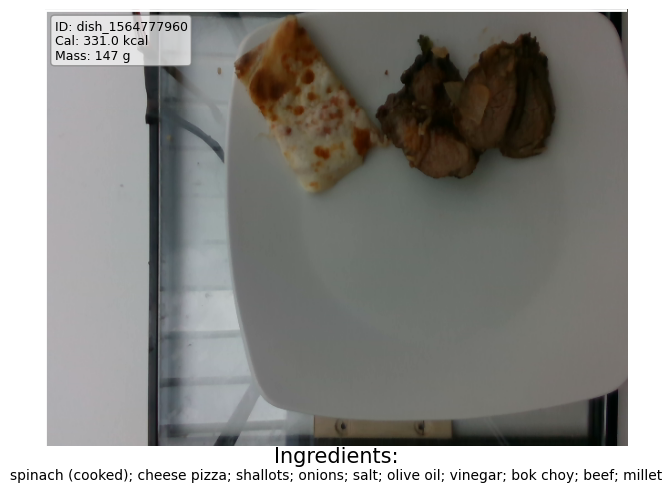

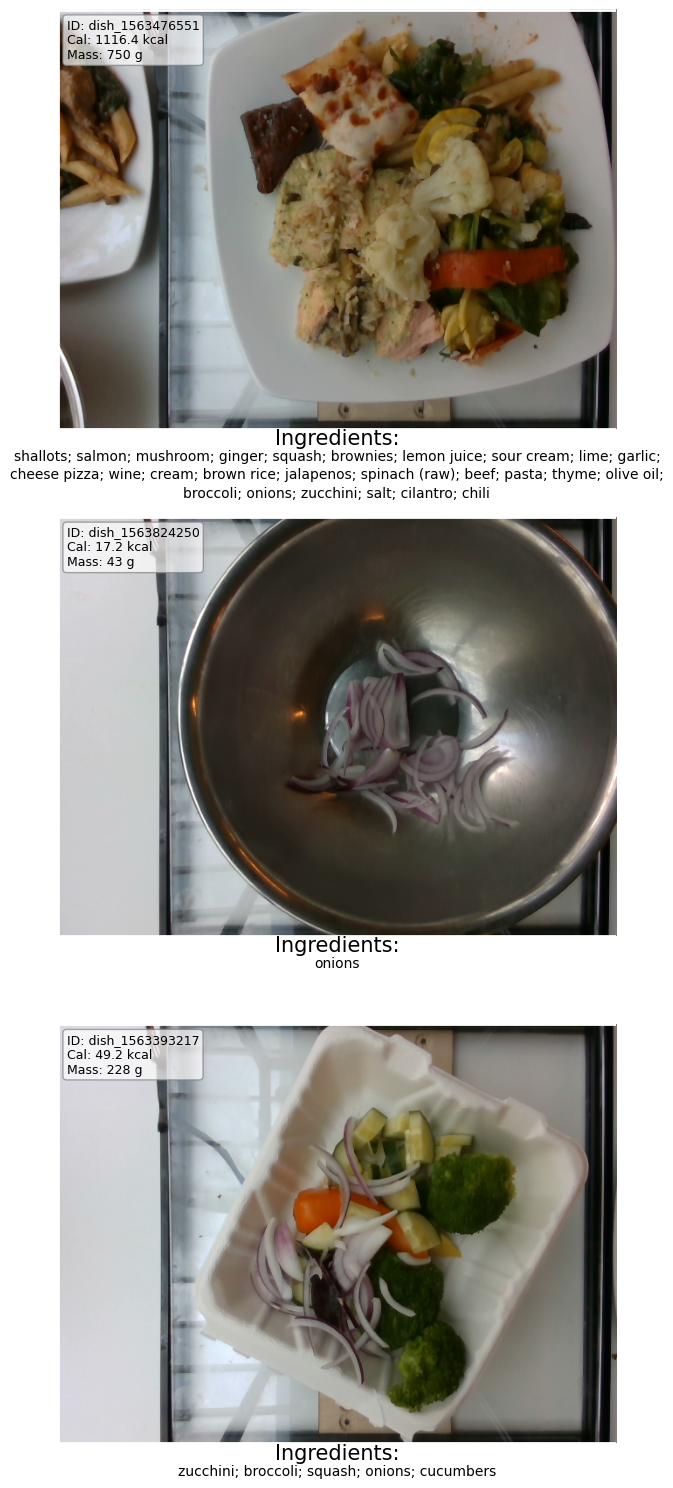

In [3]:
from DeepPlate import MultimodalDataset
from experiment_config import Config

config = Config()
train_ds = MultimodalDataset(config, split="train", transform=None)

# Показать один пример
train_ds.show_samples(42)

# Показать несколько
train_ds.show_samples([10, 20, 30], figsize_per_sample=(7, 5))

**2. Проанализируем, как подойти к задаче:**

 1) Задачу регресси будем решать с использованием дообучения мультимодальной модели, построенной на CrossAttention. В первую очередь, определимся, какие будем использовать претренированные модели на старте:

- Для изображений: "efficientnet-b3",

- Для ингредиентов: "bert-base-uncased",

- Для данных массы блюда - попробуем обучить простой MLP, должен быстро схватить взаимосвязи.

Попробуем применить следующую стратегию разморозки предобученных слоев:

- Сначала заморозить всё, обучить только  регрессионную и "массовую" головы 5 эпох,

- Разморозить последние слои (как в конфиге) еще на 15 эпох обучения.

- Полная разморозка с маленьким LR (1e-6) для тонкой настройки 10 эпох

2) Для агументации:

- Мы можем позволить себе небольшой дрифт по цветам, т.к. цвет продуктов на блюде может иметь высокую ценность. Остальные аугментации - случайный разворот, повороты, небольшой шум.

- Массу можно аугментировать достаточно смело. Например - подавать с некоторой случайностью массу чуть больше или чуть меньше. В задаче взвешивания тела всегда есть инструментальная погрешность, влияние количества воды в продукте, разные веса тарелок, - если взвешивание происходит с ними или без, поэтому, мне кажется, что нужно лишь сохранить порядок величины:
  
    - +-5% от исходной массы для небольших масс - до 200 гр,

    - и около +- 10% для блюд большей массы.

3) При обучении будем ориентироваться на MAE, считать loss через HuberLoss, выводить коэффициент детерминации ($R^2$).  


Подберем оптимальную длину паддинга

Total samples: 3262
Min length: 3
Max length: 103
Mean length: 22.6
Median length: 14.0
95th percentile: 62.0
99th percentile: 79.4


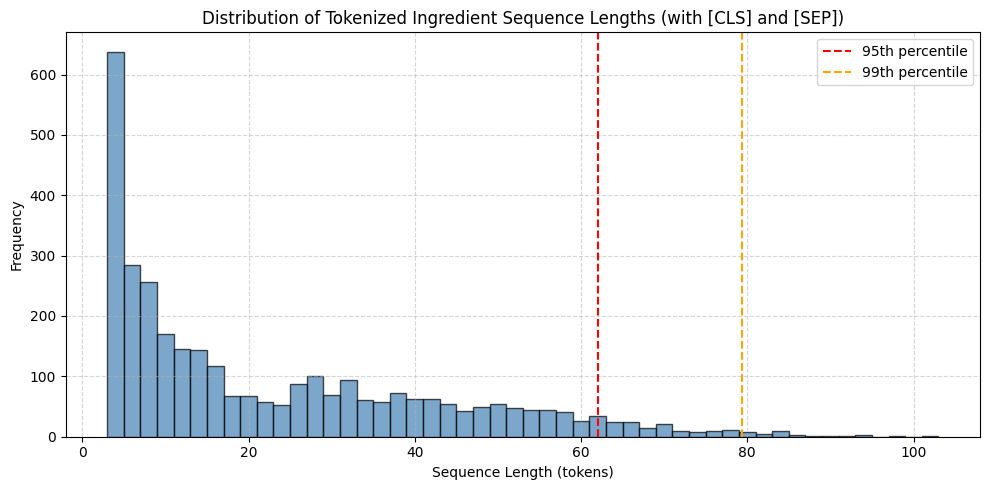

In [3]:
import pandas as pd
from pathlib import Path
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import numpy as np

# --- Paths ---
data_root = Path("data")
dish_csv = data_root / "dish.csv"
ingredients_csv = data_root / "ingredients.csv"

# --- Load data ---
dish_df = pd.read_csv(dish_csv)
ingredients_df = pd.read_csv(ingredients_csv)

# Build ingredient ID → name map
ingredients_df["id_str"] = "ingr_" + ingredients_df["id"].astype(str).str.zfill(10)
ingr_id_to_name = dict(zip(ingredients_df["id_str"], ingredients_df["ingr"]))

def parse_ingredients_text(ingr_ids_str: str) -> str:
    if not isinstance(ingr_ids_str, str) or ingr_ids_str == "":
        return ""
    ingr_ids = ingr_ids_str.split(";")
    names = [ingr_id_to_name.get(ingr_id, "") for ingr_id in ingr_ids]
    names = [name for name in names if name]
    return "; ".join(names)

# --- Convert all ingredient lists to text ---
ingredient_texts = dish_df["ingredients"].apply(parse_ingredients_text)

# --- Tokenize WITHOUT padding/truncation ---
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
lengths = []

for text in ingredient_texts:
    tokens = tokenizer.encode(text, add_special_tokens=True)  # [CLS] ... [SEP]
    lengths.append(len(tokens))

lengths = np.array(lengths)

# --- Statistics ---
print(f"Total samples: {len(lengths)}")
print(f"Min length: {lengths.min()}")
print(f"Max length: {lengths.max()}")
print(f"Mean length: {lengths.mean():.1f}")
print(f"Median length: {np.median(lengths):.1f}")
print(f"95th percentile: {np.percentile(lengths, 95):.1f}")
print(f"99th percentile: {np.percentile(lengths, 99):.1f}")

# --- Plot ---
plt.figure(figsize=(10, 5))
plt.hist(lengths, bins=50, color="steelblue", edgecolor="black", alpha=0.7)
plt.axvline(np.percentile(lengths, 95), color="red", linestyle="--", label="95th percentile")
plt.axvline(np.percentile(lengths, 99), color="orange", linestyle="--", label="99th percentile")
plt.title("Distribution of Tokenized Ingredient Sequence Lengths (with [CLS] and [SEP])")
plt.xlabel("Sequence Length (tokens)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Начну с установки Config.MAX_LENGTH = 96, думаю, это более чем оптимальный выбор.

Взглянем на выходящий элемент:

In [4]:
train_ds[10]

{'image': <PIL.Image.Image image mode=RGB size=640x480>,
 'input_ids': tensor([  101,  4618, 12868,  1025, 11840,  1025, 18565,  1025, 14580,  1025,
         18794,  1025,  2829,  3111,  1025, 14380, 10869,  1025, 14768,  6949,
          1025, 14123,  1025, 20548,  1025,  8808, 10733,  1025,  4511,  1025,
          6949,  1025,  2829,  5785,  1025, 14855,  2721, 11837,  2891,  1025,
          6714,  6776,  1006,  6315,  1007,  1025, 12486,  1025, 24857,  1025,
         15177,  4168,  1025,  9724,  3514,  1025, 22953, 21408,  3669,  1025,
         24444,  1025, 16950, 25955,  3490,  1025,  5474,  1025, 25022,  5802,
         13181,  1025, 20238,   102,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,    

Осталось подобрать аугментации:

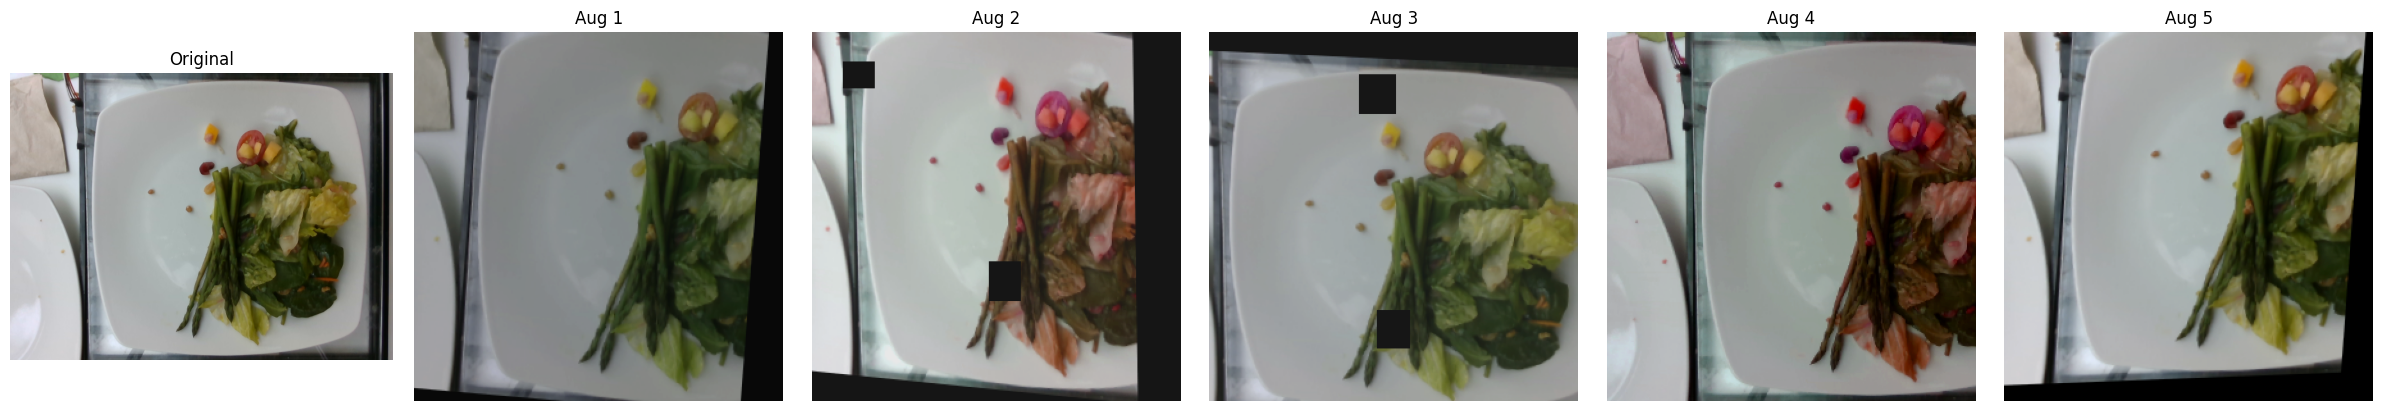

In [2]:
import os
from pathlib import Path
import pandas as pd
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

from DeepPlate import Config
from DeepPlate import get_multimodal_transforms


# --- 1. Загрузим Config и получим одно изображение ---
config = Config()

# Загрузим dish.csv и возьмём первый трейновый пример
dish_df = pd.read_csv(config.dish_csv_path)
train_df = dish_df[dish_df["split"] == "train"].reset_index(drop=True)

# Возьмём блюдо
sample_row = train_df.iloc[3]
dish_id = sample_row["dish_id"]
image_path = config.images_dir / str(dish_id) / "rgb.png"

# Загрузим как PIL → numpy
original_pil = Image.open(image_path).convert("RGB")
original_np = np.array(original_pil)

# --- 2. Получим train-трансформы ---
train_transforms = get_multimodal_transforms(config, ds_type="train")

# --- 3. Применим аугментации несколько раз ---
n_aug = 5
augmented_images = []
for i in range(n_aug):
    # albumentations ожидает numpy array с типом uint8
    transformed = train_transforms(image=original_np.copy())
    aug_tensor = transformed["image"]  # это уже torch.Tensor, нормализованный

    # Для визуализации нужно ОБРАТНО денормализовать!
    mean = np.array(train_transforms.transforms[-2].mean)  # A.Normalize mean
    std = np.array(train_transforms.transforms[-2].std)   # A.Normalize std

    # Обратное преобразование: (x_norm * std) + mean, затем в [0, 255]
    aug_np = aug_tensor.permute(1, 2, 0).numpy()
    aug_denorm = (aug_np * std) + mean
    aug_denorm = np.clip(aug_denorm, 0, 1)  # clamp to [0, 1]
    aug_denorm_uint8 = (aug_denorm * 255).astype(np.uint8)

    augmented_images.append(aug_denorm_uint8)

# --- 4. Визуализация ---
fig, axes = plt.subplots(1, n_aug + 1, figsize=(4 * (n_aug + 1), 4))

# Оригинал
axes[0].imshow(original_pil)
axes[0].set_title("Original", fontsize=12)
axes[0].axis("off")

# Аугментации
for i, aug_img in enumerate(augmented_images):
    axes[i + 1].imshow(aug_img)
    axes[i + 1].set_title(f"Aug {i+1}", fontsize=12)
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()

Такой набор аугментаций должен повысить стабильность модели при инференсе, и создать достаточный набор информации для регрессии.

Подберем аугментации для массы. Для этого оценим распределение массы для датасета

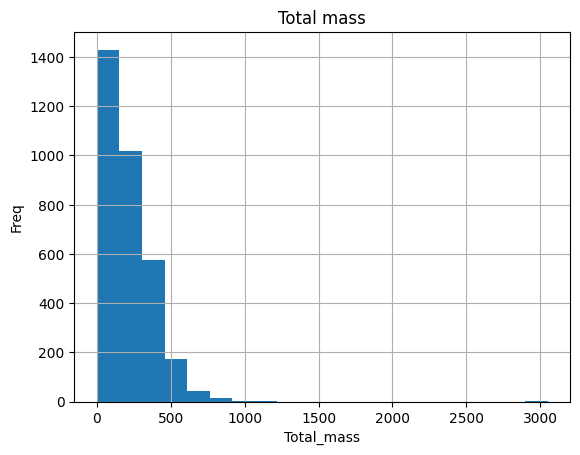

In [21]:
import matplotlib.pyplot as plt

dish_df = pd.read_csv(config.dish_csv_path)
dish_df['total_mass'].hist(bins=20)
plt.xlabel("Total_mass")
plt.ylabel("Freq")
plt.title("Total mass")
plt.show()

In [18]:
print(f"Mean mass: {dish_df['total_mass'].mean()} \nStd mass: {dish_df['total_mass'].std()}")

Mean mass: 214.98007357449418 
Std mass: 161.4974275523783


Как видно, есть выбросы, который влияют на отклонение по массе в нашем датасете и плохо скажется на регрессионной задаче. Найдем эти элементы и их количество.

In [24]:
dish_df[dish_df["total_mass"] > 6*dish_df['total_mass'].mean()]

,dish_id,total_calories,total_mass,ingredients,split
1518,dish_1560974769,3943.325195,3051.0,ingr_0000000036;ingr_0000000251;ingr_000000004...,train


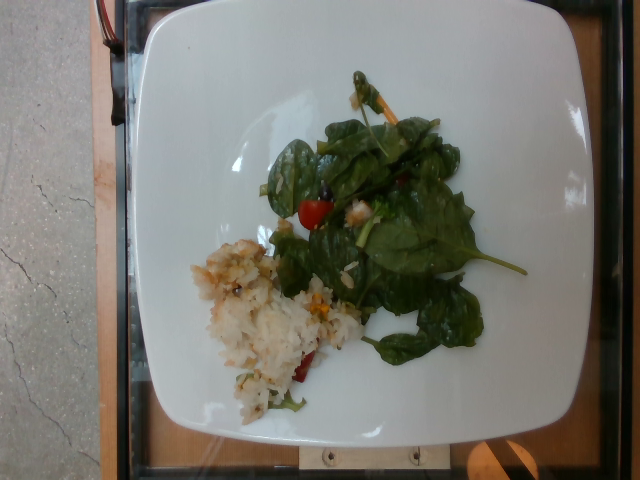

In [30]:
from IPython.display import Image
path_to_image = "data/images/dish_1560974769/rgb.png"
Image(path_to_image)

Получается всего один элемент. Думаю, его можно просто десятикратно уменьшить т.к. это будет больше похоже на правду.

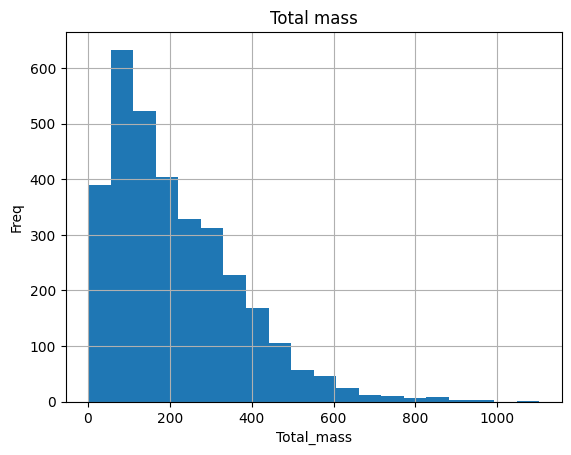

In [25]:
dish_df = pd.read_csv(config.dish_csv_path)
dish_df['total_mass'].hist(bins=20)
plt.xlabel("Total_mass")
plt.ylabel("Freq")
plt.title("Total mass")
plt.show()

In [28]:
print(f"Mean mass: {dish_df['total_mass'].mean()} \nStd mass: {dish_df['total_mass'].std()} \nMin mass: {dish_df['total_mass'].min()}\nMax mass: {dish_df['total_mass'].max()} ")

Mean mass: 214.11039558417664 
Std mass: 153.6928179441193 
Min mass: 1.0
Max mass: 1102.0 


## Этап 2. Реализуем пайплайн обучения.

Универсальный конфиг модели представлен в валидируемом файле: [experiment_config.py](./experiment_config.py)


In [1]:
from DeepPlate import Config

config = Config()

1) Реализуем загрузчики данных:

In [2]:
import torch.nn as nn
from torch.utils.data import DataLoader


from DeepPlate import (
    get_multimodal_transforms, 
    MultimodalDataset, 
    multimodal_collate_fn)

train_transforms = get_multimodal_transforms(config, "train")
val_transforms = get_multimodal_transforms(config, "val")
train_dataset = MultimodalDataset(config, split="train", transform=train_transforms)
val_dataset = MultimodalDataset(config, split="test", transform=val_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    collate_fn=multimodal_collate_fn,  # no args!
    num_workers=config.NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    collate_fn=multimodal_collate_fn,
    num_workers=config.NUM_WORKERS,
    pin_memory=True,
)

Поместим эти решения в общую функцию трейна в модуле: [train_multimodal_model.py](src/train_multimodal_model.py)

## Этап 3 Обучение модели.

In [2]:

from DeepPlate import CalorieRegressionModel
from DeepPlate import set_requires_grad
from DeepPlate import train_multimodal_model


# === 4. Создаём модель ===
model = CalorieRegressionModel(config)

# === 5. ПРИМЕНЯЕМ СТРАТЕГИЮ РАЗМОРОЗКИ (этап 1, 2 или 3) ===
set_requires_grad(model.text_model, unfreeze_pattern=config.TEXT_MODEL_UNFREEZE)
set_requires_grad(model.image_model, unfreeze_pattern=config.IMAGE_MODEL_UNFREEZE)

# === 6. Запускаем обучение ===
train_multimodal_model(model, config)

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Training on device: cuda
Starting training...


Epoch 1/2 | Train Loss: 224.0114, MAE: 224.94, R²: -1.0074 | Val Loss: 204.9535, MAE: 206.45, R²: -0.8357
New best model saved: models/best_model.pth (Val MAE: 206.45)


Epoch 2/2 | Train Loss: 187.9955, MAE: 188.16, R²: -0.5532 | Val Loss: 169.9105, MAE: 171.25, R²: -0.3810
New best model saved: models/best_model.pth (Val MAE: 171.25)
